
# Week 02 Assignment: Understanding Attention

**Course:** TECH 77 — Modern AI Architectures: From RNNs to Chatbots  
**Format:** Google Colab  
**Estimated Time:** 60–90 minutes

## Assignment Overview

In this assignment, you will explore how attention improves sequence models.

You will:

- Review the encoder–decoder bottleneck
- Implement scaled dot-product attention
- Visualize attention weights
- Build a simple sentiment classifier using multi-head attention

This is a simplified introduction and does not build a complete Transformer.



## Learning Objectives

By the end of this assignment, you should be able to:

- Explain why traditional encoder–decoder models struggle with long sequences
- Describe the purpose of attention
- Identify queries, keys, and values
- Implement scaled dot-product attention
- Explain the purpose of multi-head attention
- Build a basic attention-based text classifier


## Part 0: Setup

In [1]:

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Dropout,
    Dense
)
from tensorflow.keras.models import Model

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0



## Part 1: Encoder–Decoder Models and Attention

A traditional encoder–decoder model compresses the entire input sequence into one context vector. For long sentences, this can create an information bottleneck.

Attention improves this process by allowing the decoder to examine different encoder hidden states and focus on the most relevant parts of the input.

### Question 1

Why might compressing a long sentence into one fixed-length context vector cause a problem?

**Your answer:** Because if the context vector is of fixed length then it would not be able to store paragraphs into it because of it's limiting size. Therefore we would have to resolve this bottleneck by having a feedback loop from the decoder state to each input vector sequence.

### Question 2

Suppose a translation model is translating:

> The black cat is sleeping on the sofa.

When generating the translated word corresponding to **cat**, which source words would likely receive high attention weights?

**Your answer:**  **cat** should receive highest attention weight compared to another words while the other words receive the lowest scores summing them upto 1. Eg : Maybe cat is 0.8 and the others together could be 0.2 When translating for cat.



## Part 2: Queries, Keys, and Values

Self-attention uses three representations:

- **Query:** What information is this token looking for?
- **Key:** What information does this token contain?
- **Value:** What information should be passed forward?

Scaled dot-product attention is calculated as:

\[
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

For this small example, we will use the same vectors for queries, keys, and values.


In [2]:

tokens = ["the", "cat", "chased", "mice"]

X = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.5, 1.0, 0.5],
    [0.0, 0.0, 0.5, 1.0]
])

print("Tokens:", tokens)
print("Input shape:", X.shape)
print(X)


Tokens: ['the', 'cat', 'chased', 'mice']
Input shape: (4, 4)
[[1.  0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.5 1.  0.5]
 [0.  0.  0.5 1. ]]


In [3]:

# TODO 1:
# Set Q, K, and V equal to X.

# YOUR CODE HERE

Q = X
K = X
V = X


## Part 3: Calculate Scaled Dot-Product Attention

In [4]:

# TODO 2:
# Calculate the dot-product attention scores.
# Hint: scores = np.matmul(Q, K.T)

# YOUR CODE HERE

scores = np.matmul(Q, K.T)
print("Attention scores (QK^T):")
print(scores)

Attention scores (QK^T):
[[1.   0.   0.   0.  ]
 [0.   1.   0.5  0.  ]
 [0.   0.5  1.5  1.  ]
 [0.   0.   1.   1.25]]


In [5]:

# TODO 3:
# Scale the scores by dividing by the square root of d_k.
# Hint: d_k = K.shape[-1]

# YOUR CODE HERE
d_k = K.shape[-1]
scaled_scores = scores / np.sqrt(d_k)
print("d_k:", d_k)
print("Scaled scores:")
print(scaled_scores)

d_k: 4
Scaled scores:
[[0.5   0.    0.    0.   ]
 [0.    0.5   0.25  0.   ]
 [0.    0.25  0.75  0.5  ]
 [0.    0.    0.5   0.625]]


In [6]:

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# TODO 4:
# Apply softmax to the scaled scores.

# YOUR CODE HERE

attention_weights = softmax(scaled_scores)

print("Attention weights:")
print(np.round(attention_weights, 3))

print("\nRow sums:")
print(np.round(attention_weights.sum(axis=1), 3))


Attention weights:
[[0.355 0.215 0.215 0.215]
 [0.203 0.334 0.26  0.203]
 [0.165 0.212 0.35  0.273]
 [0.181 0.181 0.299 0.339]]

Row sums:
[1. 1. 1. 1.]



### Question 3

Why are the attention scores divided by \(\sqrt{d_k}\)?

**Your answer:** The Attention scores are divided to contain the large magnitude shoot up of the dot product similarity scores when the dimesions of the Key values increase drastically.Dividing by square root (d_k) would normalize all of the similarity scores.

### Question 4

Why should every row of the attention-weight matrix add up to approximately 1?

**Your answer:** Because softmax is a probabilty function where the maximum probabity of any sample set is 1 and least is 0. Since it's a relative measure of each input with a mean of all the inputs it would have a high peak distribution along with relative to that distribution making the total area of distribution to be 1. In this scenario , based on the attention scores we would have the highest attention score on the relevant word and lowest attention scores for the others summing everything to be 1.


## Part 4: Visualize the Attention Weights

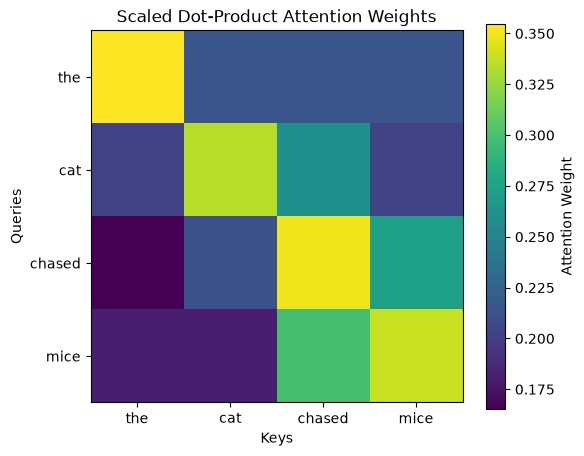

In [7]:

# TODO 5:
# Create a heatmap of the attention weights.

plt.figure(figsize=(6, 5))

# Add plt.imshow() here
plt.imshow(attention_weights, cmap='viridis')

plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.title("Scaled Dot-Product Attention Weights")

# Add a color bar here

plt.colorbar(label="Attention Weight")
plt.show()



### Question 5

Examine the row corresponding to **chased**. Which word or words receive the highest attention weights?

**Your answer:** The highest received attention weight word is **'Chased'** with relative 2nd highest being mice in the row od chased.


In [8]:

# TODO 6:
# Calculate the final attention output.
# Hint: multiply attention_weights by V.

# YOUR CODE HERE
attention_output = np.matmul(attention_weights, V)
print("Attention output:")
print(np.round(attention_output, 3))


Attention output:
[[0.355 0.323 0.323 0.323]
 [0.203 0.464 0.362 0.333]
 [0.165 0.387 0.486 0.447]
 [0.181 0.331 0.468 0.488]]



## Part 5: Build a Simple Multi-Head Attention Model

We will now build a small sentiment classifier using the IMDb movie review dataset.

The model will include:

- An embedding layer
- A multi-head attention layer
- A pooling layer
- A binary classification output

This is an attention-based classifier, not a complete Transformer.


In [9]:

vocab_size = 5000
max_len = 100

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

# Use smaller subsets to keep training fast
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:3000]
y_test = y_test[:3000]

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))


Training samples: 10000
Testing samples: 3000


In [13]:

# TODO 7:
# Pad the training and testing sequences.
# Use padding="post" and truncating="post".

# YOUR CODE HERE
x_train_padded = pad_sequences(x_train, maxlen=max_len, padding="post", truncating="post")
x_test_padded = pad_sequences(x_test, maxlen=max_len, padding="post", truncating="post")
print("Training shape:", x_train_padded.shape)
print("Testing shape:", x_test_padded.shape)


Training shape: (10000, 100)
Testing shape: (3000, 100)


In [10]:

embedding_dim = 32
num_heads = 2
key_dim = 16

inputs = Input(shape=(max_len,))

# TODO 8:
# Add an Embedding layer and apply it to inputs.
x = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
# YOUR CODE HERE

# TODO 9:
# Add a MultiHeadAttention layer.
# Since this is self-attention, use x as both query and value.

# YOUR CODE HERE
attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
x = GlobalAveragePooling1D()(attention_output)
x = Dropout(0.2)(x)
x = Dense(32, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs=inputs, outputs=outputs)

# TODO 10:
# Compile the model using adam, binary_crossentropy, and accuracy.

# YOUR CODE HERE
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 32)   │    160,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 32)   │      4,224 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 165,313 (645.75 KB)

 Trainable params: 165,313 (645.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:

history = model.fit(
    x_train_padded,
    y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6300 - loss: 0.6379 - val_accuracy: 0.7925 - val_loss: 0.4650
Epoch 2/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8267 - loss: 0.3902 - val_accuracy: 0.8135 - val_loss: 0.4253


In [15]:

# TODO 11:
# Evaluate the model on the test set.

# YOUR CODE HERE
test_loss, test_accuracy = model.evaluate(x_test_padded, y_test)
print("Test accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8160 - loss: 0.4284
Test accuracy: 0.8159999847412109


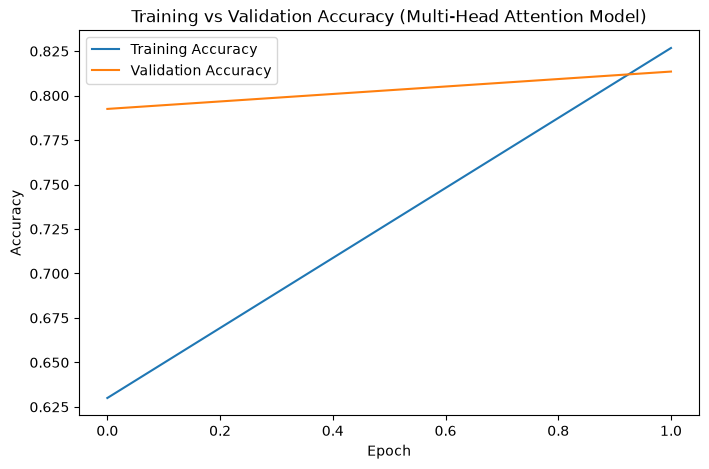

In [17]:

# TODO 12:
# Plot training accuracy and validation accuracy.

# YOUR CODE HERE
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Multi-Head Attention Model)")
plt.legend()
plt.show()


## Final Reflection

Answer each question in 2–4 sentences.

### 1. What problem does attention solve in an encoder–decoder model?

**Your answer:** It would solve single context problem along with the attention of a word in a sentence with the help of probability

### 2. How does self-attention create context-dependent representations?

**Your answer:** Unlike the static embeddings that were represent with a vector representaion for a word. The self attention recomputes each token's representation with respect to the other words in the sentence with the help of dot product relation to attain a probability score for the word with respect the context that is surrounded in. Thus differentiating savings bank vs river bank when it looks for the relationship of bank with respect to the context.

### 3. Why might multi-head attention be more useful than a single attention head?

**Your answer:** Multi head attention would investigate more relationship with the same word as it contains atleast twice the weights of the self attention model where it only contains a single relationship with the same word. Hence giving the model more computational opportunity to look into different perspective than a single perspective.

### 4. How is this model different from the RNN model built in Week 1?

**Your answer:** In Week-1 We built RNN model using single context state which would only allow the model to run a sequential execution whereas in week-2 we build self-attention and multi-head attention model which enables the model to parallely process the tokens simultaneously at a moment and achieve the relationship or context between the words. 

### 5. What components are still missing from a complete Transformer?

**Your answer:** Postional encoding, Feed forward network and a decoder architecture are something that we are missing to completely form a transformer. 



## Submission Checklist

Before submitting, make sure your notebook includes:

- Completed attention calculations
- Attention-weight heatmap
- Final attention output
- Padded IMDb sequences
- Trained multi-head attention model
- Test accuracy
- Training and validation accuracy plot
- Answers to all questions and reflections
